<a href="https://colab.research.google.com/github/nurulfdlharba-dotcom/rf-dataset-sekunder/blob/hasil1/hasil1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving dataset1.csv to dataset1 (1).csv


# 1. Import library

In [ ]:
# Pengolahan data
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Evaluasi model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# 2. Load dataset

In [ ]:
# Membaca dataset CSV
df = pd.read_csv('/content/dataset1.csv')

# Menampilkan 5 data pertama
print(df.head())

# Menampilkan jumlah baris dan kolom
print("Ukuran dataset:", df.shape)

# Menampilkan nama-nama kolom
print("Nama kolom:", df.columns.tolist())

     N    P    K    pH    EC    OC     S    Zn    Fe    Cu    Mn     B  Output
0  138  8.6  560  7.46  0.62  0.70   5.9  0.24  0.31  0.77  8.71  0.11       0
1  213  7.5  338  7.62  0.75  1.06  25.4  0.30  0.86  1.54  2.89  2.29       0
2  163  9.6  718  7.59  0.51  1.11  14.3  0.30  0.86  1.57  2.70  2.03       0
3  157  6.8  475  7.64  0.58  0.94  26.0  0.34  0.54  1.53  2.65  1.82       0
4  270  9.9  444  7.63  0.40  0.86  11.8  0.25  0.76  1.69  2.43  2.26       1
Ukuran dataset: (880, 13)
Nama kolom: ['N', 'P', 'K', 'pH', 'EC', 'OC', 'S', 'Zn', 'Fe', 'Cu', 'Mn', 'B', 'Output']


# 3. Cleaning dataset

In [ ]:
# Mengecek kondisi dataset sebelum cleaning
print("=== KONDISI DATASET SEBELUM CLEANING ===")

# Menampilkan informasi dataset
print("\nInformasi Dataset:")
print(df.info())

# Mengecek missing value
print("\nJumlah Missing Value:")
print(df.isnull().sum())

# Mengecek data duplikat
print("\nJumlah Data Duplikat:")
print(df.duplicated().sum())

=== KONDISI DATASET SEBELUM CLEANING ===

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 880 entries, 0 to 879
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   N       880 non-null    int64  
 1   P       880 non-null    float64
 2   K       880 non-null    int64  
 3   pH      880 non-null    float64
 4   EC      880 non-null    float64
 5   OC      880 non-null    float64
 6   S       880 non-null    float64
 7   Zn      880 non-null    float64
 8   Fe      880 non-null    float64
 9   Cu      880 non-null    float64
 10  Mn      880 non-null    float64
 11  B       880 non-null    float64
 12  Output  880 non-null    int64  
dtypes: float64(10), int64(3)
memory usage: 89.5 KB
None

Jumlah Missing Value:
N         0
P         0
K         0
pH        0
EC        0
OC        0
S         0
Zn        0
Fe        0
Cu        0
Mn        0
B         0
Output    0
dtype: int64

Jumlah Data Duplikat:
0


In [ ]:
# Menghapus data duplikat
df = df.drop_duplicates()

# Menghapus data yang memiliki missing value
df = df.dropna()

# Mengatur ulang index
df = df.reset_index(drop=True)

In [ ]:
# Mengecek kondisi dataset setelah cleaning
print("=== KONDISI DATASET SETELAH CLEANING ===")

# Menampilkan ukuran dataset
print("\nUkuran Dataset:")
print(df.shape)

# Mengecek missing value
print("\nJumlah Missing Value:")
print(df.isnull().sum())

# Mengecek data duplikat
print("\nJumlah Data Duplikat:")
print(df.duplicated().sum())

# Menampilkan 5 data pertama
print("\n5 Data Pertama:")
print(df.head())

=== KONDISI DATASET SETELAH CLEANING ===

Ukuran Dataset:
(880, 13)

Jumlah Missing Value:
N         0
P         0
K         0
pH        0
EC        0
OC        0
S         0
Zn        0
Fe        0
Cu        0
Mn        0
B         0
Output    0
dtype: int64

Jumlah Data Duplikat:
0

5 Data Pertama:
     N    P    K    pH    EC    OC     S    Zn    Fe    Cu    Mn     B  Output
0  138  8.6  560  7.46  0.62  0.70   5.9  0.24  0.31  0.77  8.71  0.11       0
1  213  7.5  338  7.62  0.75  1.06  25.4  0.30  0.86  1.54  2.89  2.29       0
2  163  9.6  718  7.59  0.51  1.11  14.3  0.30  0.86  1.57  2.70  2.03       0
3  157  6.8  475  7.64  0.58  0.94  26.0  0.34  0.54  1.53  2.65  1.82       0
4  270  9.9  444  7.63  0.40  0.86  11.8  0.25  0.76  1.69  2.43  2.26       1


# 4. EDA

In [ ]:
# Statistik deskriptif dataset
print("=== STATISTIK DESKRIPTIF ===")
print(df[['N', 'P', 'K', 'pH', 'EC']].describe())

=== STATISTIK DESKRIPTIF ===
               N           P           K          pH          EC
count  880.00000  880.000000  880.000000  880.000000  880.000000
mean   246.73750   14.562159  499.978409    7.510500    0.543659
std     77.38886   21.967755  124.222838    0.464912    0.141597
min      6.00000    2.900000   11.000000    0.900000    0.100000
25%    201.00000    6.800000  412.000000    7.350000    0.430000
50%    257.00000    8.100000  475.000000    7.500000    0.545000
75%    307.00000   10.550000  581.000000    7.630000    0.640000
max    383.00000  125.000000  887.000000   11.150000    0.950000


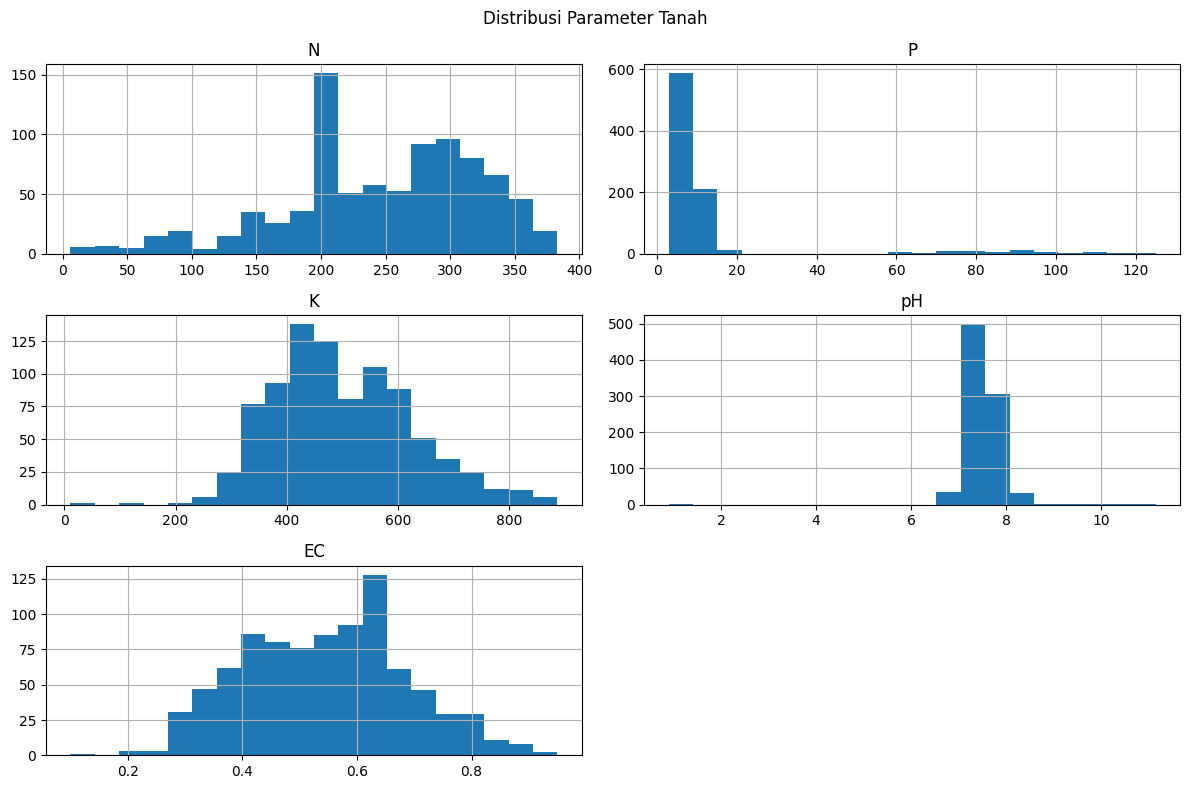

In [ ]:
# Visualisasi distribusi data
df[['N', 'P', 'K', 'pH', 'EC']].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle('Distribusi Parameter Tanah')
plt.tight_layout()
plt.show()

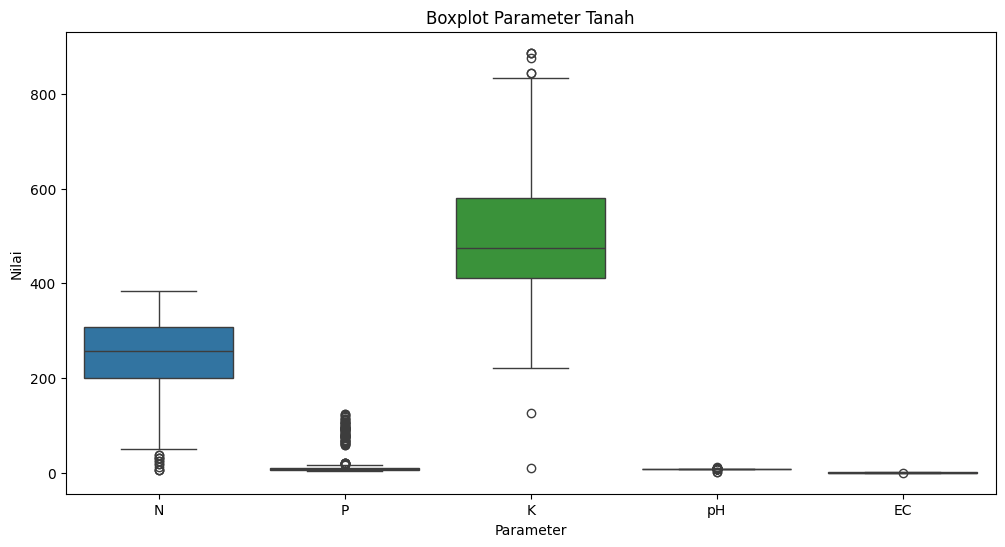

In [ ]:
# Boxplot untuk melihat outlier
plt.figure(figsize=(12, 6))

sns.boxplot(data=df[['N', 'P', 'K', 'pH', 'EC']])

plt.title('Boxplot Parameter Tanah')
plt.xlabel('Parameter')
plt.ylabel('Nilai')
plt.show()

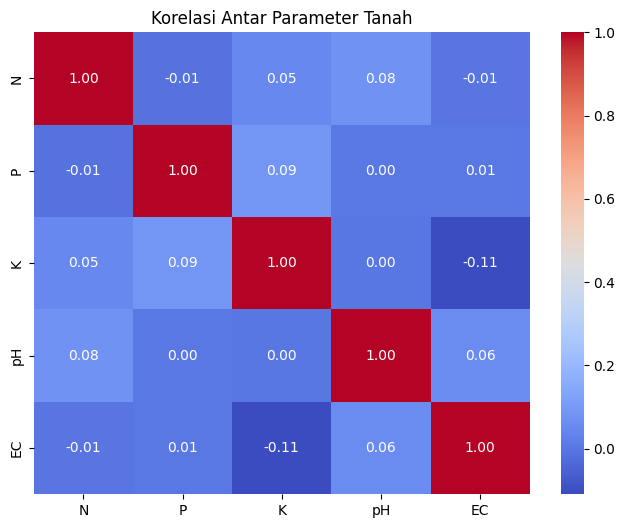

In [ ]:
# Melihat korelasi antar parameter
plt.figure(figsize=(8, 6))

sns.heatmap(
    df[['N', 'P', 'K', 'pH', 'EC']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Korelasi Antar Parameter Tanah')
plt.show()

# 5. Persiapan data untuk K-Means

In [ ]:
from sklearn.preprocessing import StandardScaler

# Memilih fitur yang digunakan
features = ['N', 'P', 'K', 'pH', 'EC']

# Membuat salinan data fitur
X = df[features].copy()

# Konversi EC dari dS/m ke µS/cm
X['EC'] = X['EC'] * 1000

# Standardisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Menampilkan 5 data hasil standardisasi
print("Data setelah standardisasi:")
print(X_scaled[:5])

Data setelah standardisasi:
[[-1.40587851 -0.27155936  0.48345155 -0.10868444  0.53944992]
 [-0.43619567 -0.32166123 -1.30467572  0.2356623   1.45807258]
 [-1.08265089 -0.22601221  1.75608266  0.17109728 -0.23784618]
 [-1.16022552 -0.35354424 -0.20119178  0.27870564  0.25679679]
 [ 0.3007633  -0.21234807 -0.45088522  0.25718397 -1.01514228]]


In [ ]:
print(X[['EC']].head())

      EC
0  620.0
1  750.0
2  510.0
3  580.0
4  400.0


# 6. K-Means

In [ ]:
from sklearn.cluster import KMeans

# Membuat model K-Means dengan 5 cluster
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

# Melakukan clustering
clusters = kmeans.fit_predict(X_scaled)

# Menambahkan hasil cluster ke dataset
df['Cluster'] = clusters

# Menampilkan jumlah data pada setiap cluster
print("Jumlah data setiap cluster:")
print(df['Cluster'].value_counts().sort_index())

Jumlah data setiap cluster:
Cluster
0    322
1    273
2    216
3     67
4      2
Name: count, dtype: int64


# 7. Melihat centroid setiap cluster

In [ ]:
# Mengambil posisi centroid dalam skala asli
centroids_scaled = kmeans.cluster_centers_

# Mengembalikan centroid ke satuan asli
centroids = scaler.inverse_transform(centroids_scaled)

# Membuat tabel centroid
centroid_df = pd.DataFrame(
    centroids,
    columns=features
)

centroid_df.index.name = 'Cluster'

print("Centroid setiap cluster:")
print(centroid_df)

Centroid setiap cluster:
                  N          P           K        pH          EC
Cluster                                                         
0        231.993789   8.220807  418.130435  7.527857  646.583851
1        230.252747   8.190842  486.794872  7.432234  399.267399
2        293.810185   9.159722  631.851852  7.644491  572.129630
3        231.194030  88.574627  525.641791  7.511343  545.671642
4        307.500000   9.250000  375.000000  0.900000  540.000000


In [ ]:
# Melihat data asli Cluster 4
print("=== DATA CLUSTER 4 ===")
print(df[df['Cluster'] == 4][features])

=== DATA CLUSTER 4 ===
       N    P    K   pH    EC
519  301  9.9  359  0.9  0.52
521  314  8.6  391  0.9  0.56


In [ ]:
# Melihat data asli Cluster 3
print("\n=== STATISTIK CLUSTER 3 ===")
print(df[df['Cluster'] == 3][features].describe())


=== STATISTIK CLUSTER 3 ===
                N           P           K         pH         EC
count   67.000000   67.000000   67.000000  67.000000  67.000000
mean   231.194030   88.574627  525.641791   7.511343   0.545672
std     68.690619   17.758987  145.162156   0.247802   0.126888
min     31.000000   59.200000  232.000000   7.100000   0.340000
25%    201.000000   74.600000  422.000000   7.350000   0.435000
50%    226.000000   89.900000  486.000000   7.430000   0.530000
75%    276.000000  100.900000  649.500000   7.580000   0.625000
max    383.000000  125.000000  834.000000   8.190000   0.830000


# 8. Pemeriksaan pH ekstrem

In [ ]:
print("=== DISTRIBUSI NILAI pH ===")
print(df['pH'].describe())

print("\n=== DATA DENGAN pH < 4 ===")
print(df[df['pH'] < 4][features])

=== DISTRIBUSI NILAI pH ===
count    880.000000
mean       7.510500
std        0.464912
min        0.900000
25%        7.350000
50%        7.500000
75%        7.630000
max       11.150000
Name: pH, dtype: float64

=== DATA DENGAN pH < 4 ===
       N    P    K   pH    EC
519  301  9.9  359  0.9  0.52
521  314  8.6  391  0.9  0.56


In [ ]:
print("=== DATA DENGAN pH > 8.5 ===")
print(df[df['pH'] > 8.5][features])

=== DATA DENGAN pH > 8.5 ===
       N     P    K     pH    EC
355  176   6.1  444   9.97  0.35
529  301  12.7  422   8.95  0.39
530  282  15.6  602   9.50  0.42
531  295  13.4  412  10.05  0.73
532  326  11.8  444  10.60  0.88
533  358  12.5  581  11.15  0.51


In [ ]:
print("\nJumlah data pH > 8.5:")
print((df['pH'] > 8.5).sum())


Jumlah data pH > 8.5:
6


In [ ]:
# Melihat 8 data pH ekstrem
print("=== DATA pH EKSTREM ===")

extreme_ph = df[(df['pH'] < 4) | (df['pH'] > 8.5)]

print(extreme_ph[features])

=== DATA pH EKSTREM ===
       N     P    K     pH    EC
355  176   6.1  444   9.97  0.35
519  301   9.9  359   0.90  0.52
521  314   8.6  391   0.90  0.56
529  301  12.7  422   8.95  0.39
530  282  15.6  602   9.50  0.42
531  295  13.4  412  10.05  0.73
532  326  11.8  444  10.60  0.88
533  358  12.5  581  11.15  0.51


In [ ]:
print("=== DATA LENGKAP pH EKSTREM ===")
print(df.loc[extreme_ph.index])

=== DATA LENGKAP pH EKSTREM ===
       N     P    K     pH    EC    OC      S    Zn    Fe    Cu     Mn     B  \
355  176   6.1  444   9.97  0.35  0.78   8.14  0.74  4.36  0.54  12.05  0.34   
519  301   9.9  359   0.90  0.52  0.88   8.14  0.43  6.33  1.25   8.96  0.32   
521  314   8.6  391   0.90  0.56  0.98   3.92  0.51  1.78  0.60   7.58  0.21   
529  301  12.7  422   8.95  0.39  0.49   8.75  0.67  5.91  0.89  13.52  0.44   
530  282  15.6  602   9.50  0.42  0.20   5.13  0.60  5.70  1.07   7.54  0.34   
531  295  13.4  412  10.05  0.73  0.68   6.33  0.52  3.31  1.89   3.25  0.48   
532  326  11.8  444  10.60  0.88  0.88   8.75  0.43  6.52  0.85   8.05  0.27   
533  358  12.5  581  11.15  0.51  0.49  11.16  0.28  4.13  1.23  11.03  0.36   

     Output  Cluster  
355       0        1  
519       1        4  
521       1        4  
529       1        1  
530       1        2  
531       1        0  
532       1        2  
533       2        2  


# 9. Filtering pH ekstrem

In [ ]:
# Menghapus data dengan pH ekstrem untuk proses clustering
df_model = df[(df['pH'] >= 4.5) & (df['pH'] <= 8.5)].copy()

print("Jumlah data sebelum:", len(df))
print("Jumlah data setelah:", len(df_model))
print("Jumlah data yang dikeluarkan:", len(df) - len(df_model))

print("\nRentang pH setelah filtering:")
print(df_model['pH'].min(), "sampai", df_model['pH'].max())

Jumlah data sebelum: 880
Jumlah data setelah: 872
Jumlah data yang dikeluarkan: 8

Rentang pH setelah filtering:
6.96 sampai 8.4


In [ ]:
print("\n=== CEK pH EKSTREM ===")
print(df_model[(df_model['pH'] < 4.5) | (df_model['pH'] > 8.5)])


=== CEK pH EKSTREM ===
Empty DataFrame
Columns: [N, P, K, pH, EC, OC, S, Zn, Fe, Cu, Mn, B, Output, Cluster]
Index: []


# 10. Standarisasi ulang

In [ ]:
from sklearn.preprocessing import StandardScaler

features = ['N', 'P', 'K', 'pH', 'EC']

X = df_model[features].copy()

# dS/m → µS/cm
X['EC'] = X['EC'] * 1000

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("=== DATA SEBELUM STANDARDISASI ===")
print(X.head())

print("\n=== DATA SETELAH STANDARDISASI ===")
print(X_scaled[:5])

=== DATA SEBELUM STANDARDISASI ===
     N    P    K    pH     EC
0  138  8.6  560  7.46  620.0
1  213  7.5  338  7.62  750.0
2  163  9.6  718  7.59  510.0
3  157  6.8  475  7.64  580.0
4  270  9.9  444  7.63  400.0

=== DATA SETELAH STANDARDISASI ===
[[-1.39891183 -0.27171594  0.4792981  -0.18213948  0.54055929]
 [-0.43016095 -0.32159822 -1.30522403  0.42147336  1.46092277]
 [-1.07599487 -0.22636841  1.7493634   0.30829595 -0.23820982]
 [-1.15349494 -0.35334149 -0.20396488  0.49692496  0.25737052]
 [ 0.30608973 -0.21276415 -0.4531549   0.45919916 -1.01697892]]


# 11. K-Means 5 cluster

In [ ]:
from sklearn.cluster import KMeans

# K-Means dengan 5 cluster
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

# Membentuk cluster
clusters = kmeans.fit_predict(X_scaled)

# Simpan hasil cluster
df_model['Cluster_Baru'] = clusters

print("=== JUMLAH DATA SETIAP CLUSTER ===")
print(df_model['Cluster_Baru'].value_counts().sort_index())

=== JUMLAH DATA SETIAP CLUSTER ===
Cluster_Baru
0    182
1    249
2    230
3     67
4    144
Name: count, dtype: int64


# 12. Melihat centroid setiap cluster

In [ ]:
# Mengambil posisi centroid dalam bentuk standar
centroids_scaled = kmeans.cluster_centers_

# Mengembalikan centroid ke satuan asli
centroids = scaler.inverse_transform(centroids_scaled)

# Membuat tabel centroid
centroid_df = pd.DataFrame(
    centroids,
    columns=features
)

centroid_df.index.name = 'Cluster'

print("=== CENTROID SETIAP CLUSTER ===")
print(centroid_df)

=== CENTROID SETIAP CLUSTER ===
                  N          P           K        pH          EC
Cluster                                                         
0        144.109290   7.177049  461.912568  7.514973  549.344262
1        272.705645   8.708065  453.879032  7.447298  669.516129
2        269.060870   8.639565  547.378261  7.316000  412.391304
3        231.194030  88.574627  525.641791  7.511343  545.671642
4        301.381944   9.232639  542.493056  7.910486  528.333333


# 13. Interpretasi cluster (5 kelas kesuburan)

In [ ]:
# Nilai ideal berdasarkan acuan proyek
ideal = {
    'N': 200,
    'P': 300,
    'K': 500,
    'pH': 6.8,
    'EC': 700
}

# Membuat tabel perbandingan centroid dengan nilai ideal
comparison = centroid_df.copy()

for parameter in features:
    comparison[f'{parameter}_Ideal'] = ideal[parameter]

print("=== PERBANDINGAN CENTROID DENGAN NILAI IDEAL ===")
print(comparison)

=== PERBANDINGAN CENTROID DENGAN NILAI IDEAL ===
                  N          P           K        pH          EC  N_Ideal  \
Cluster                                                                     
0        144.109290   7.177049  461.912568  7.514973  549.344262      200   
1        272.705645   8.708065  453.879032  7.447298  669.516129      200   
2        269.060870   8.639565  547.378261  7.316000  412.391304      200   
3        231.194030  88.574627  525.641791  7.511343  545.671642      200   
4        301.381944   9.232639  542.493056  7.910486  528.333333      200   

         P_Ideal  K_Ideal  pH_Ideal  EC_Ideal  
Cluster                                        
0            300      500       6.8       700  
1            300      500       6.8       700  
2            300      500       6.8       700  
3            300      500       6.8       700  
4            300      500       6.8       700  


In [ ]:
# Menghitung selisih absolut terhadap nilai ideal
distance = centroid_df.copy()

for parameter in features:
    distance[parameter] = (
        centroid_df[parameter] - ideal[parameter]
    ).abs()

print("=== JARAK CENTROID TERHADAP NILAI IDEAL ===")
print(distance)

=== JARAK CENTROID TERHADAP NILAI IDEAL ===
                  N           P          K        pH          EC
Cluster                                                         
0         55.890710  292.822951  38.087432  0.714973  150.655738
1         72.705645  291.291935  46.120968  0.647298   30.483871
2         69.060870  291.360435  47.378261  0.516000  287.608696
3         31.194030  211.425373  25.641791  0.711343  154.328358
4        101.381944  290.767361  42.493056  1.110486  171.666667


In [ ]:
print("=== RENTANG DATASET 872 DATA ===")

for parameter in features:
    print(
        f"{parameter}: "
        f"min = {X[parameter].min():.2f}, "
        f"max = {X[parameter].max():.2f}, "
        f"mean = {X[parameter].mean():.2f}"
    )

=== RENTANG DATASET 872 DATA ===
N: min = 6.00, max = 383.00, mean = 246.30
P: min = 2.90, max = 125.00, mean = 14.59
K: min = 11.00, max = 887.00, mean = 500.37
pH: min = 6.96, max = 8.40, mean = 7.51
EC: min = 100.00, max = 950.00, mean = 543.65


In [ ]:
print("\n=== NILAI IDEAL ===")

for parameter in features:
    print(f"{parameter}: {ideal[parameter]}")


=== NILAI IDEAL ===
N: 200
P: 300
K: 500
pH: 6.8
EC: 700


In [42]:
# Membuat ranking relatif setiap parameter
ranking = centroid_df.copy()

for parameter in features:
    ranking[parameter + '_Rank'] = (
        centroid_df[parameter]
        .rank(method='min', ascending=True)
    )

print("=== RANKING CENTROID SETIAP PARAMETER ===")

for parameter in features:
    print(f"\n{parameter}:")
    print(
        ranking[[parameter, parameter + '_Rank']]
        .sort_values(parameter)
    )

=== RANKING CENTROID SETIAP PARAMETER ===

N:
                  N  N_Rank
Cluster                    
0        144.109290     1.0
3        231.194030     2.0
2        269.060870     3.0
1        272.705645     4.0
4        301.381944     5.0

P:
                 P  P_Rank
Cluster                   
0         7.177049     1.0
2         8.639565     2.0
1         8.708065     3.0
4         9.232639     4.0
3        88.574627     5.0

K:
                  K  K_Rank
Cluster                    
1        453.879032     1.0
0        461.912568     2.0
3        525.641791     3.0
4        542.493056     4.0
2        547.378261     5.0

pH:
               pH  pH_Rank
Cluster                   
2        7.316000      1.0
1        7.447298      2.0
3        7.511343      3.0
0        7.514973      4.0
4        7.910486      5.0

EC:
                 EC  EC_Rank
Cluster                     
2        412.391304      1.0
4        528.333333      2.0
3        545.671642      3.0
0        549.344262  

# 14. Ranking relatif setiap parameter

In [43]:
# Membuat ranking relatif centroid
ranking = centroid_df.copy()

for parameter in ['N', 'P', 'K', 'pH', 'EC']:
    ranking[parameter + '_Rank'] = (
        centroid_df[parameter]
        .rank(method='min', ascending=True)
    )

print("=== RANKING RELATIF SETIAP PARAMETER ===")

for parameter in ['N', 'P', 'K', 'pH', 'EC']:
    print(f"\n--- {parameter} ---")
    print(
        ranking[[parameter, parameter + '_Rank']]
        .sort_values(parameter)
    )

=== RANKING RELATIF SETIAP PARAMETER ===

--- N ---
                  N  N_Rank
Cluster                    
0        144.109290     1.0
3        231.194030     2.0
2        269.060870     3.0
1        272.705645     4.0
4        301.381944     5.0

--- P ---
                 P  P_Rank
Cluster                   
0         7.177049     1.0
2         8.639565     2.0
1         8.708065     3.0
4         9.232639     4.0
3        88.574627     5.0

--- K ---
                  K  K_Rank
Cluster                    
1        453.879032     1.0
0        461.912568     2.0
3        525.641791     3.0
4        542.493056     4.0
2        547.378261     5.0

--- pH ---
               pH  pH_Rank
Cluster                   
2        7.316000      1.0
1        7.447298      2.0
3        7.511343      3.0
0        7.514973      4.0
4        7.910486      5.0

--- EC ---
                 EC  EC_Rank
Cluster                     
2        412.391304      1.0
4        528.333333      2.0
3        545.671

# 15. Ranking relatif centroid

In [44]:
# Ranking relatif N, P, dan K
ranking = centroid_df.copy()

for parameter in ['N', 'P', 'K']:
    ranking[parameter + '_Rank'] = (
        centroid_df[parameter]
        .rank(method='min', ascending=True)
    )

print("=== RANKING RELATIF N, P, K ===")

for parameter in ['N', 'P', 'K']:
    print(f"\n--- {parameter} ---")
    print(
        ranking[[parameter, parameter + '_Rank']]
        .sort_values(parameter)
    )

=== RANKING RELATIF N, P, K ===

--- N ---
                  N  N_Rank
Cluster                    
0        144.109290     1.0
3        231.194030     2.0
2        269.060870     3.0
1        272.705645     4.0
4        301.381944     5.0

--- P ---
                 P  P_Rank
Cluster                   
0         7.177049     1.0
2         8.639565     2.0
1         8.708065     3.0
4         9.232639     4.0
3        88.574627     5.0

--- K ---
                  K  K_Rank
Cluster                    
1        453.879032     1.0
0        461.912568     2.0
3        525.641791     3.0
4        542.493056     4.0
2        547.378261     5.0


In [45]:
# Nilai referensi
pH_ref = 6.8
EC_ref = 700

interpretasi = centroid_df.copy()

# Jarak dari nilai referensi
interpretasi['pH_Jarak'] = abs(interpretasi['pH'] - pH_ref)
interpretasi['EC_Jarak'] = abs(interpretasi['EC'] - EC_ref)

print("=== JARAK pH DAN EC TERHADAP REFERENSI ===")
print(
    interpretasi[
        ['N', 'P', 'K', 'pH', 'EC', 'pH_Jarak', 'EC_Jarak']
    ]
)

=== JARAK pH DAN EC TERHADAP REFERENSI ===
                  N          P           K        pH          EC  pH_Jarak  \
Cluster                                                                      
0        144.109290   7.177049  461.912568  7.514973  549.344262  0.714973   
1        272.705645   8.708065  453.879032  7.447298  669.516129  0.647298   
2        269.060870   8.639565  547.378261  7.316000  412.391304  0.516000   
3        231.194030  88.574627  525.641791  7.511343  545.671642  0.711343   
4        301.381944   9.232639  542.493056  7.910486  528.333333  1.110486   

           EC_Jarak  
Cluster              
0        150.655738  
1         30.483871  
2        287.608696  
3        154.328358  
4        171.666667  


In [46]:
# Membuat skor rata-rata NPK
score_npk = ranking[['N_Rank', 'P_Rank', 'K_Rank']].mean(axis=1)

print("=== SKOR RATA-RATA NPK ===")
print(score_npk.sort_values())

=== SKOR RATA-RATA NPK ===
Cluster
0    1.333333
1    2.666667
2    3.333333
3    3.333333
4    4.333333
dtype: float64


In [47]:
# Membuat tabel skor
score_df = pd.DataFrame(index=centroid_df.index)

# 1. Skor NPK
score_df['NPK_Score'] = score_npk

# 2. Skor kesesuaian pH
# Semakin dekat ke 6.8, semakin tinggi skornya
ph_distance = abs(centroid_df['pH'] - 6.8)
score_df['pH_Score'] = 1 - (
    ph_distance / ph_distance.max()
)

# 3. Skor kesesuaian EC
# Semakin dekat ke 700, semakin tinggi skornya
ec_distance = abs(centroid_df['EC'] - 700)
score_df['EC_Score'] = 1 - (
    ec_distance / ec_distance.max()
)

print("=== SKOR CLUSTER ===")
print(score_df)

=== SKOR CLUSTER ===
         NPK_Score  pH_Score  EC_Score
Cluster                               
0         1.333333  0.356162  0.476178
1         2.666667  0.417104  0.894009
2         3.333333  0.535339  0.000000
3         3.333333  0.359431  0.463409
4         4.333333  0.000000  0.403124


In [48]:
# Normalisasi NPK Score menjadi 0-1
score_df['NPK_Normalized'] = (
    score_df['NPK_Score'] - score_df['NPK_Score'].min()
) / (
    score_df['NPK_Score'].max() - score_df['NPK_Score'].min()
)

print("=== SKOR SETELAH NORMALISASI ===")
print(score_df)

=== SKOR SETELAH NORMALISASI ===
         NPK_Score  pH_Score  EC_Score  NPK_Normalized
Cluster                                               
0         1.333333  0.356162  0.476178        0.000000
1         2.666667  0.417104  0.894009        0.444444
2         3.333333  0.535339  0.000000        0.666667
3         3.333333  0.359431  0.463409        0.666667
4         4.333333  0.000000  0.403124        1.000000


In [49]:
# Bobot
w_npk = 0.60
w_ph = 0.25
w_ec = 0.15

# Menghitung skor gabungan
score_df['Composite_Score'] = (
    w_npk * score_df['NPK_Normalized'] +
    w_ph * score_df['pH_Score'] +
    w_ec * score_df['EC_Score']
)

print("=== COMPOSITE SCORE ===")
print(
    score_df[
        ['NPK_Normalized', 'pH_Score', 'EC_Score', 'Composite_Score']
    ].sort_values('Composite_Score')
)

=== COMPOSITE SCORE ===
         NPK_Normalized  pH_Score  EC_Score  Composite_Score
Cluster                                                     
0              0.000000  0.356162  0.476178         0.160467
1              0.444444  0.417104  0.894009         0.505044
2              0.666667  0.535339  0.000000         0.533835
3              0.666667  0.359431  0.463409         0.559369
4              1.000000  0.000000  0.403124         0.660469


# validasi hasil label

In [50]:
# Membuat tabel interpretasi cluster
final_cluster = centroid_df.copy()

final_cluster['NPK_Score'] = score_df['NPK_Score']
final_cluster['pH_Score'] = score_df['pH_Score']
final_cluster['EC_Score'] = score_df['EC_Score']
final_cluster['Composite_Score'] = score_df['Composite_Score']

# Ranking berdasarkan Composite Score
final_cluster['Ranking'] = (
    final_cluster['Composite_Score']
    .rank(method='min', ascending=True)
    .astype(int)
)

# Label sementara
label_map = {
    1: 'Sangat Rendah',
    2: 'Rendah',
    3: 'Sedang',
    4: 'Tinggi',
    5: 'Sangat Tinggi'
}

final_cluster['Label_Sementara'] = (
    final_cluster['Ranking'].map(label_map)
)

print("=== HASIL INTERPRETASI CLUSTER ===")
print(
    final_cluster[
        ['N', 'P', 'K', 'pH', 'EC',
         'NPK_Score', 'pH_Score', 'EC_Score',
         'Composite_Score', 'Ranking',
         'Label_Sementara']
    ].sort_values('Ranking')
)

=== HASIL INTERPRETASI CLUSTER ===
                  N          P           K        pH          EC  NPK_Score  \
Cluster                                                                       
0        144.109290   7.177049  461.912568  7.514973  549.344262   1.333333   
1        272.705645   8.708065  453.879032  7.447298  669.516129   2.666667   
2        269.060870   8.639565  547.378261  7.316000  412.391304   3.333333   
3        231.194030  88.574627  525.641791  7.511343  545.671642   3.333333   
4        301.381944   9.232639  542.493056  7.910486  528.333333   4.333333   

         pH_Score  EC_Score  Composite_Score  Ranking Label_Sementara  
Cluster                                                                
0        0.356162  0.476178         0.160467        1   Sangat Rendah  
1        0.417104  0.894009         0.505044        2          Rendah  
2        0.535339  0.000000         0.533835        3          Sedang  
3        0.359431  0.463409         0.559369       

# Split data

In [51]:
# Mapping cluster ke tingkat kesuburan
label_map = {
    0: 'Sangat Rendah',
    1: 'Rendah',
    2: 'Sedang',
    3: 'Tinggi',
    4: 'Sangat Tinggi'
}

# Membuat label kesuburan
df_model['Kesuburan'] = df_model['Cluster_Baru'].map(label_map)

print("=== CONTOH DATA DENGAN LABEL ===")
print(df_model[['N', 'P', 'K', 'pH', 'EC', 'Cluster_Baru', 'Kesuburan']].head(10))

=== CONTOH DATA DENGAN LABEL ===
     N    P    K    pH    EC  Cluster_Baru      Kesuburan
0  138  8.6  560  7.46  0.62             0  Sangat Rendah
1  213  7.5  338  7.62  0.75             1         Rendah
2  163  9.6  718  7.59  0.51             0  Sangat Rendah
3  157  6.8  475  7.64  0.58             0  Sangat Rendah
4  270  9.9  444  7.63  0.40             2         Sedang
5  220  8.6  444  7.43  0.65             1         Rendah
6  220  7.2  222  7.62  0.43             0  Sangat Rendah
7  207  7.0  401  7.63  0.59             0  Sangat Rendah
8  289  8.6  560  7.58  0.44             2         Sedang
9  138  8.1  739  7.55  0.33             2         Sedang


In [52]:
print("\n=== JUMLAH DATA SETIAP KELAS ===")
print(
    df_model['Kesuburan']
    .value_counts()
    .reindex([
        'Sangat Rendah',
        'Rendah',
        'Sedang',
        'Tinggi',
        'Sangat Tinggi'
    ])
)


=== JUMLAH DATA SETIAP KELAS ===
Kesuburan
Sangat Rendah    182
Rendah           249
Sedang           230
Tinggi            67
Sangat Tinggi    144
Name: count, dtype: int64


In [53]:
print("\n=== CEK LABEL KOSONG ===")
print(df_model['Kesuburan'].isnull().sum())


=== CEK LABEL KOSONG ===
0


# Siapkan data

In [54]:
# Fitur untuk Random Forest
features = ['N', 'P', 'K', 'pH', 'EC']

X_rf = df_model[features].copy()

# Konversi EC dari dS/m → µS/cm
X_rf['EC'] = X_rf['EC'] * 1000

# Target
y = df_model['Kesuburan']

print("=== FITUR (X) ===")
print(X_rf.head())

print("\n=== TARGET (y) ===")
print(y.head())

=== FITUR (X) ===
     N    P    K    pH     EC
0  138  8.6  560  7.46  620.0
1  213  7.5  338  7.62  750.0
2  163  9.6  718  7.59  510.0
3  157  6.8  475  7.64  580.0
4  270  9.9  444  7.63  400.0

=== TARGET (y) ===
0    Sangat Rendah
1           Rendah
2    Sangat Rendah
3    Sangat Rendah
4           Sedang
Name: Kesuburan, dtype: object


In [55]:
print("\nUkuran X:", X_rf.shape)
print("Ukuran y:", y.shape)


Ukuran X: (872, 5)
Ukuran y: (872,)


# 18. Train-Test split

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_rf,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=== UKURAN DATA ===")
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

=== UKURAN DATA ===
X_train : (697, 5)
X_test  : (175, 5)
y_train : (697,)
y_test  : (175,)


In [57]:
print("\n=== DISTRIBUSI KELAS TRAINING ===")
print(y_train.value_counts())

print("\n=== DISTRIBUSI KELAS TESTING ===")
print(y_test.value_counts())


=== DISTRIBUSI KELAS TRAINING ===
Kesuburan
Rendah           199
Sedang           184
Sangat Rendah    145
Sangat Tinggi    115
Tinggi            54
Name: count, dtype: int64

=== DISTRIBUSI KELAS TESTING ===
Kesuburan
Rendah           50
Sedang           46
Sangat Rendah    37
Sangat Tinggi    29
Tinggi           13
Name: count, dtype: int64


# 19.Training random forest

In [58]:
from sklearn.ensemble import RandomForestClassifier

# Membuat model Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Melatih model
rf_model.fit(X_train, y_train)

print("Random Forest berhasil dilatih.")

Random Forest berhasil dilatih.


# 20.Prediksi menggunakan data testing

In [59]:
# Melakukan prediksi pada data testing
y_pred = rf_model.predict(X_test)

print("=== HASIL PREDIKSI ===")
print(y_pred[:20])

=== HASIL PREDIKSI ===
['Sedang' 'Rendah' 'Sedang' 'Rendah' 'Sedang' 'Sedang' 'Rendah' 'Sedang'
 'Sangat Tinggi' 'Sangat Rendah' 'Sangat Rendah' 'Sedang' 'Rendah'
 'Sedang' 'Sangat Rendah' 'Sangat Tinggi' 'Sangat Tinggi' 'Tinggi'
 'Sedang' 'Tinggi']


# 21.Evaluasi performa

In [60]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Menghitung metrik evaluasi
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)

print("=== HASIL EVALUASI RANDOM FOREST ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

=== HASIL EVALUASI RANDOM FOREST ===
Accuracy  : 0.9543
Precision : 0.9551
Recall    : 0.9543
F1-Score  : 0.9540


In [61]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Prediksi data testing
y_pred = rf_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("=== HASIL EVALUASI RANDOM FOREST ===")
print(f"Accuracy : {accuracy:.4f}")

print("\n=== CLASSIFICATION REPORT ===")

print(
    classification_report(
        y_test,
        y_pred,
        labels=[
            'Sangat Rendah',
            'Rendah',
            'Sedang',
            'Tinggi',
            'Sangat Tinggi'
        ],
        digits=4,
        zero_division=0
    )
)

=== HASIL EVALUASI RANDOM FOREST ===
Accuracy : 0.9543

=== CLASSIFICATION REPORT ===
               precision    recall  f1-score   support

Sangat Rendah     0.9429    0.8919    0.9167        37
       Rendah     0.9796    0.9600    0.9697        50
       Sedang     0.9200    1.0000    0.9583        46
       Tinggi     1.0000    1.0000    1.0000        13
Sangat Tinggi     0.9643    0.9310    0.9474        29

     accuracy                         0.9543       175
    macro avg     0.9613    0.9566    0.9584       175
 weighted avg     0.9551    0.9543    0.9540       175



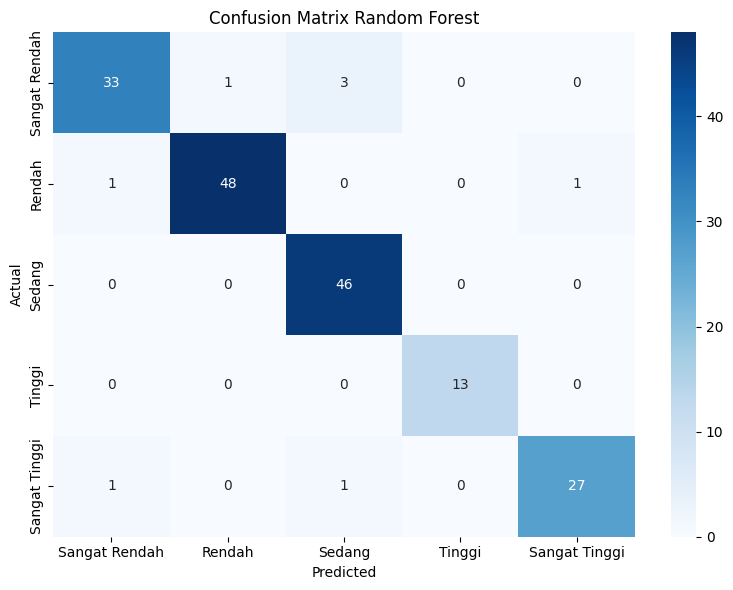

In [64]:
# =========================
# 2. CONFUSION MATRIX
# =========================

import matplotlib.pyplot as plt
import seaborn as sns

labels = [
    'Sangat Rendah',
    'Rendah',
    'Sedang',
    'Tinggi',
    'Sangat Tinggi'
]

cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',        # Biru → putih
    xticklabels=labels,
    yticklabels=labels
)

plt.title('Confusion Matrix Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# 22.Cross validation

In [65]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    rf_model,
    X_rf,
    y,
    cv=cv,
    scoring='accuracy'
)

print("=== HASIL 5-FOLD CROSS VALIDATION ===")

for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nMean Accuracy : {cv_scores.mean():.4f}")
print(f"Std Deviation : {cv_scores.std():.4f}")

=== HASIL 5-FOLD CROSS VALIDATION ===
Fold 1: 0.9257
Fold 2: 0.9314
Fold 3: 0.8966
Fold 4: 0.9310
Fold 5: 0.9540

Mean Accuracy : 0.9278
Std Deviation : 0.0184


# 13. Feature Importance

In [66]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_rf.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("=== FEATURE IMPORTANCE ===")
print(feature_importance)

=== FEATURE IMPORTANCE ===
  Feature  Importance
4      EC    0.267302
3      pH    0.260300
0       N    0.230189
1       P    0.163325
2       K    0.078884


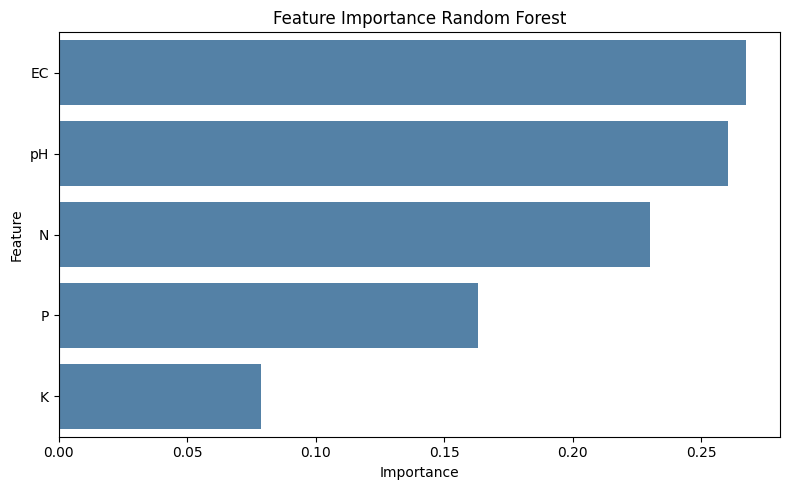

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature',
    color='steelblue'
)

plt.title('Feature Importance Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()